# M3 — The Learned Corrections: δ_R and δ_F Close the Analytic Gaps

**Inelastic coding prompt 4, task 4** (2026-08-25). M3 trained two bounded
Flax heads on the L23 X-difference truth channels and committed their
weights (4.2 + 4.3 kB): δ_R rescales the analytic Raman *increment*
(`f_R = 1 + (f_phys − 1)(1 + δ_R)`), δ_F rescales the φ_C-linear
fluorescence kernel (`Rrs_fl = φ_C · K_fl (1 + δ_F)`, **no φ_C input** — the
yield stays a clean retrieval handle). With the weights committed, the
corrected model is `forward`'s default (`corrections=None`; the analytic
terms remain one flag away via `corrections=False` — JXP-approved, prompt 4
Q&A Q1).

The M3 code gate is green: on **held-out scenes** the per-process median
errors are ≤ 5 % at every zenith *including 0°* — beaten ~25×
(record §5.3–5.4). This notebook shows the before/after, the trophic-tail
diagnostic, and — honestly — where the heads must *not* be trusted: an
unseen solar zenith. Everything here recomputes from the committed weights
on the full release; no number is trained in this notebook except the
deliberately-crippled zenith-holdout variant of §3.


In [1]:
import sys
from pathlib import Path

REPO = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / 'robust' / '__init__.py').exists())
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

import jax
import numpy as np

from robust.rt import inelastic as I
from robust.rt import inelastic_corr as IC
from robust.rt.data import l23 as L

batch = L.load_inelastic_batch()          # the full release ($OS_COLOR)
splits = L.make_splits(batch)             # the elastic splits, verbatim
heads = IC.load_default()                 # the committed weights
wave = np.asarray(batch.wave)
i685 = int(np.abs(wave - 685.0).argmin())
held = splits.scene_test

f_phys = np.asarray(I.raman_factor(batch.iops, batch.geometry, batch.wave))
d_r = np.asarray(heads.raman.delta(batch.iops, batch.geometry, batch.wave))
f_corr = np.asarray(IC.corrected_raman_factor(d_r, f_phys))
f_truth = np.asarray(batch.truth_raman_factor)

k_fl = np.asarray(I.fluorescence_kernel(batch.iops, batch.geometry, batch.wave))
d_f = np.asarray(heads.fl.delta(batch.iops, batch.geometry, batch.wave))
fl_analytic = L.PHI_C_L23 * k_fl
fl_corr = fl_analytic * (1.0 + d_f)
fl_truth = np.asarray(batch.truth_fluorescence)

n_par = sum(np.asarray(p).size for p in jax.tree_util.tree_leaves(heads.raman.params))
print(f'repo: {REPO}; jax {jax.__version__} on {jax.default_backend()}')
print(f'full release: {batch.n_sample} samples; {int(held.sum())} held-out')
print(f'params per head: {n_par} (elastic emulator: 417); '
      f'max |delta_R| {np.abs(d_r).max():.3f} (bound '
      f'{heads.raman.config.delta_max}), max |delta_F| {np.abs(d_f).max():.3f} '
      f'(bound {heads.fl.config.delta_max})')

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


repo: /mnt/tank/Oceanography/python/retrieve-or-bust; jax 0.11.1 on cpu
full release: 9960 samples; 1992 held-out
params per head: 129 (elastic emulator: 417); max |delta_R| 0.905 (bound 1.0), max |delta_F| 0.338 (bound 0.5)


## 1. Raman, before and after — the −39 % @ 0° line is gone

Median increment error per wavelength on held-out scenes. The analytic
backbone (M2) was right at 30–60° over 550–700 nm but −38.6 % at 0° and
+30 % near 490 nm; δ_R — 129 parameters, bounded by 1.0 — flattens all of
it to a fraction of a percent. The correction is *on the increment*, so
`f_R → 1` wherever Raman vanishes no matter what the network says.


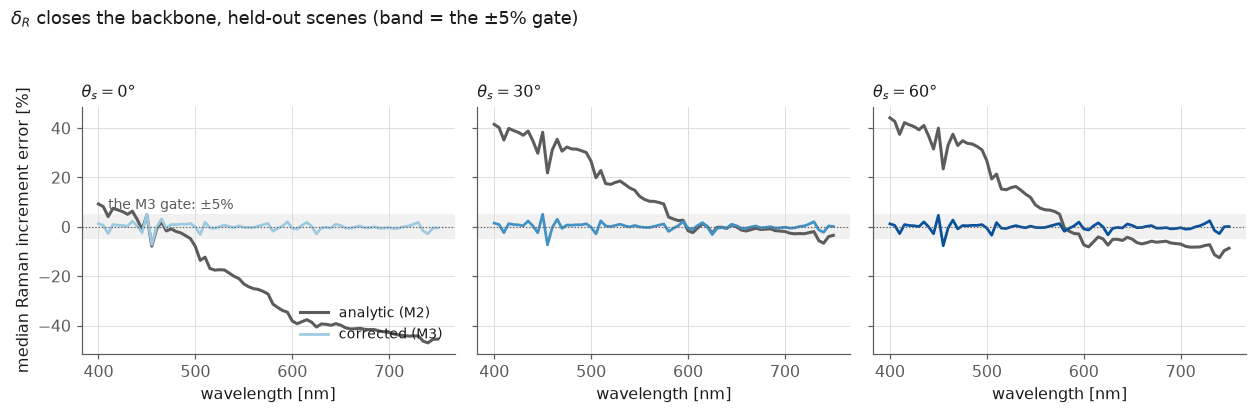

held-out medians, analytic -> corrected:
   0 deg:  550-700 -38.56% ->  -0.14%    490 nm  -3.60% ->  +1.03%
  30 deg:  550-700  +1.23% ->  -0.10%    490 nm +30.85% ->  +0.82%
  60 deg:  550-700  -4.21% ->  -0.21%    490 nm +32.55% ->  +0.58%


In [2]:
import matplotlib as mpl
import matplotlib.pyplot as plt

INK, INK_MUTED, GRID = '#1a1a1a', '#5c5c5c', '#dcdcdc'
BLUES = {0.0: '#9ecae1', 30.0: '#4292c6', 60.0: '#08519c'}
ORANGE = '#D55E00'
mpl.rcParams.update({
    'figure.dpi': 110, 'savefig.dpi': 110, 'font.size': 10.5,
    'axes.edgecolor': INK_MUTED, 'axes.labelcolor': INK, 'text.color': INK,
    'xtick.color': INK_MUTED, 'ytick.color': INK_MUTED,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.color': GRID, 'grid.linewidth': 0.6,
    'legend.frameon': False, 'figure.facecolor': 'white', 'axes.facecolor': 'white',
})

inc_err_before = (f_phys - 1.0) / (f_truth - 1.0) - 1.0
inc_err_after = (f_corr - 1.0) / (f_truth - 1.0) - 1.0

vis = wave >= 400.0  # the official band; below it the excitation clamps
fig, axes = plt.subplots(1, 3, figsize=(11.5, 3.8), sharey=True)
for ax, (theta, color) in zip(axes, BLUES.items()):
    rows = held & (batch.zenith == theta)
    ax.plot(wave[vis], 100 * np.median(inc_err_before[rows], axis=0)[vis],
            color=INK_MUTED, lw=2.0, label='analytic (M2)')
    ax.plot(wave[vis], 100 * np.median(inc_err_after[rows], axis=0)[vis],
            color=color, lw=1.8, label='corrected (M3)')
    ax.axhline(0, color=INK_MUTED, lw=0.8, ls=':')
    ax.axhspan(-5, 5, color=GRID, alpha=0.4, lw=0)
    ax.set_title(f'$\\theta_s = {theta:.0f}°$', fontsize=10.5, loc='left')
    ax.set_xlabel('wavelength [nm]')
axes[0].set_ylabel('median Raman increment error [%]')
axes[0].legend(loc='lower right', fontsize=9)
axes[0].annotate('the M3 gate: $\\pm$5%', xy=(410, 7), fontsize=9,
                 color=INK_MUTED)
fig.suptitle('$\\delta_R$ closes the backbone, held-out scenes '
             '(band = the $\\pm$5% gate)', x=0.01, ha='left', fontsize=11.5)
fig.tight_layout(rect=(0, 0, 1, 0.93))
plt.show()

band = (wave >= 550) & (wave <= 700)
i490 = int(np.abs(wave - 490).argmin())
print('held-out medians, analytic -> corrected:')
for theta in (0.0, 30.0, 60.0):
    rows = held & (batch.zenith == theta)
    b = 100 * np.median(inc_err_before[rows][:, band])
    a = 100 * np.median(inc_err_after[rows][:, band])
    b4 = 100 * np.median(inc_err_before[rows][:, i490])
    a4 = 100 * np.median(inc_err_after[rows][:, i490])
    print(f'  {theta:2.0f} deg:  550-700 {b:+6.2f}% -> {a:+6.2f}%    '
          f'490 nm {b4:+6.2f}% -> {a4:+6.2f}%')

## 2. Fluorescence, before and after — and the trophic tail stays flat

Left: the 685 nm error per zenith collapses from the analytic drift
(−13.7 % at 60° on the full release) to ~0.1 %. Right: the a_ph(440)-decile
diagnostic on held-out scenes — the eutrophic-tail risk the coding plan
watches — is flat to ±0.6 % across two orders of magnitude in biomass.
δ_F never sees φ_C, so the retrieval handle `∂Rrs/∂φ_C = K_fl(1 + δ_F)`
survives training untouched (pinned by test).


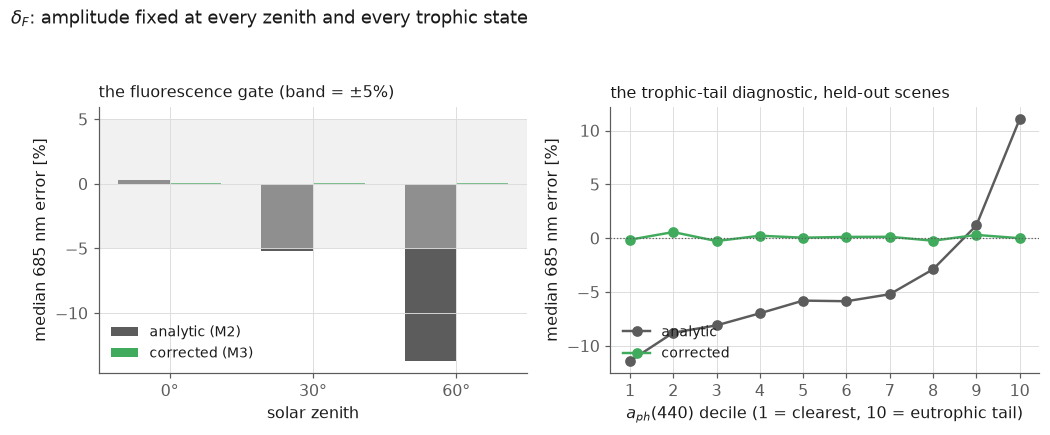

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9.6, 4.0))

thetas = (0.0, 30.0, 60.0)
err_b = [100 * (np.median(fl_analytic[held & (batch.zenith == t), i685]
                          / fl_truth[held & (batch.zenith == t), i685]) - 1)
         for t in thetas]
err_a = [100 * (np.median(fl_corr[held & (batch.zenith == t), i685]
                          / fl_truth[held & (batch.zenith == t), i685]) - 1)
         for t in thetas]
x = np.arange(3)
ax1.bar(x - 0.18, err_b, width=0.36, color=INK_MUTED, label='analytic (M2)')
ax1.bar(x + 0.18, err_a, width=0.36, color='#41ab5d', label='corrected (M3)')
ax1.axhspan(-5, 5, color=GRID, alpha=0.4, lw=0)
ax1.set_xticks(x, [f'{t:.0f}°' for t in thetas])
ax1.set_xlabel('solar zenith')
ax1.set_ylabel('median 685 nm error [%]')
ax1.set_title('the fluorescence gate (band = $\\pm$5%)',
              fontsize=10.5, loc='left')
ax1.legend(loc='lower left', fontsize=9)

aph440 = np.asarray(batch.iops.a_ph)[:, np.abs(wave - 440).argmin()]
edges = np.quantile(aph440[held], np.linspace(0, 1, 11))
mids, dec_b, dec_a = [], [], []
for d in range(10):
    rows = held & (aph440 >= edges[d]) & (aph440 <= edges[d + 1])
    mids.append(d + 1)
    dec_b.append(100 * np.median(fl_analytic[rows, i685] / fl_truth[rows, i685] - 1))
    dec_a.append(100 * np.median(fl_corr[rows, i685] / fl_truth[rows, i685] - 1))
ax2.plot(mids, dec_b, 'o-', color=INK_MUTED, lw=1.6, label='analytic')
ax2.plot(mids, dec_a, 'o-', color='#41ab5d', lw=1.6, label='corrected')
ax2.axhline(0, color=INK_MUTED, lw=0.8, ls=':')
ax2.set_xticks(mids)
ax2.set_xlabel('$a_{ph}(440)$ decile (1 = clearest, 10 = eutrophic tail)')
ax2.set_ylabel('median 685 nm error [%]')
ax2.set_title('the trophic-tail diagnostic, held-out scenes',
              fontsize=10.5, loc='left')
ax2.legend(loc='lower left', fontsize=9)
fig.suptitle('$\\delta_F$: amplitude fixed at every zenith and every '
             'trophic state', x=0.01, ha='left', fontsize=11.5)
fig.tight_layout(rect=(0, 0, 1, 0.93))
plt.show()

## 3. The honest panel: an unseen solar zenith breaks δ_R

The geometry-generalization diagnostic (elastic CQ6): retrain δ_R with 60°
**excluded** (train 0°/30° only, same architecture, same loss) and evaluate
where it never looked. The result is not mild degradation — at 60° the
crippled head drives the increment error to ≈ **−74 %**, far *worse* than
the −4 % analytic backbone it was supposed to correct. (δ_F degrades more
gently, to −9.2 % at 3000 steps — better than the analytic −13.7 %, still
past the gate.)

**Caption to remember:** these heads are *interpolators in cos θ_s*. Inside
the trained geometry they beat the gate by ~25×; one step outside they are
worse than no correction at all. Any future use at other geometries needs
training coverage or a domain guard like the elastic emulator's
(`Emulator.domain`) — this is the same lesson JXP set as policy there, now
re-measured on the inelastic side. The shipped weights train on **all
three** zeniths; this crippled variant exists only in this notebook and the
training script's report.


    step     0  loss  25.948  fit  25.948%  |delta|rms  0.000%


    step   500  loss   2.571  fit   1.869%  |delta|rms 35.128%


    step  1000  loss   2.449  fit   1.744%  |delta|rms 35.242%


    step  1499  loss   2.399  fit   1.693%  |delta|rms 35.271%
    39 s for 1500 steps


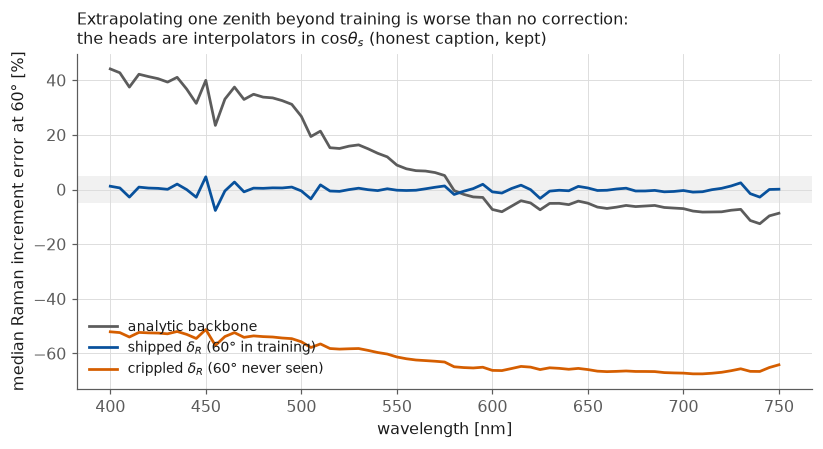

crippled head at unseen 60 deg, 550-700 nm median: -65.5% (shipped: -0.21%; training-script 3000-step run measured -74%)


In [4]:
import importlib.util

spec = importlib.util.spec_from_file_location(
    'train_inelastic_corr', REPO / 'design' / 'py' / 'train_inelastic_corr.py')
T = importlib.util.module_from_spec(spec)
spec.loader.exec_module(T)

x_raman = np.asarray(IC.features_raman(batch.iops, batch.geometry, batch.wave))
holdout_mask = splits.scene_train & splits.zenith_train  # 0 and 30 deg only
band_loss = (wave >= T.RAMAN_BAND[0]) & (wave <= T.RAMAN_BAND[1])

import jax.numpy as jnp
inc_truth = jnp.asarray(f_truth[holdout_mask][:, band_loss] - 1.0)
inc_phys = jnp.asarray(f_phys[holdout_mask][:, band_loss] - 1.0)

def raman_loss(delta):
    rel = inc_phys * (1.0 + delta[:, band_loss]) / inc_truth - 1.0
    return 100.0 * jnp.sqrt(jnp.mean(rel**2) + T.EPS)

head_ho = T.fit_head(T.RAMAN_CONFIG, x_raman, holdout_mask, raman_loss, steps=1500)
d_ho = np.asarray(head_ho.delta(batch.iops, batch.geometry, batch.wave))
f_ho = np.asarray(IC.corrected_raman_factor(d_ho, f_phys))
inc_err_ho = (f_ho - 1.0) / (f_truth - 1.0) - 1.0

fig, ax = plt.subplots(figsize=(7.6, 4.2))
rows60 = held & (batch.zenith == 60.0)
vis = wave >= 400.0
ax.plot(wave[vis], 100 * np.median(inc_err_before[rows60], axis=0)[vis],
        color=INK_MUTED, lw=1.8, label='analytic backbone')
ax.plot(wave[vis], 100 * np.median(inc_err_after[rows60], axis=0)[vis],
        color='#08519c', lw=1.8, label='shipped $\\delta_R$ (60° in training)')
ax.plot(wave[vis], 100 * np.median(inc_err_ho[rows60], axis=0)[vis],
        color=ORANGE, lw=1.8, label='crippled $\\delta_R$ (60° never seen)')
ax.axhspan(-5, 5, color=GRID, alpha=0.4, lw=0)
ax.set_xlabel('wavelength [nm]')
ax.set_ylabel('median Raman increment error at 60° [%]')
ax.set_title('Extrapolating one zenith beyond training is worse than no '
             'correction:\nthe heads are interpolators in cos$\\theta_s$ '
             '(honest caption, kept)', fontsize=10.5, loc='left')
ax.legend(loc='lower left', fontsize=9)
fig.tight_layout()
plt.show()

b = 100 * np.median(inc_err_ho[rows60][:, band])
print(f'crippled head at unseen 60 deg, 550-700 nm median: {b:+.1f}% '
      f'(shipped: {100 * np.median(inc_err_after[rows60][:, band]):+.2f}%; '
      'training-script 3000-step run measured -74%)')

## 4. The economics, and what M4 inherits

Each head is a single 16-wide layer — **129 parameters**, about a third of
the elastic emulator's 417, on targets the analytic backbone already brings
within 30 %: the physics carries the shape, the network pays only for the
residual. Nothing demanded growth (the design budgeted up to O(10³)).

**State entering M4 (validation):** the full composed forward —
`(Rrs_ZTT + ΔRrs) × f_R + φ_C·K_fl(1 + δ_F)` — is the default `forward`,
differentiable end to end (the corrected-path FD gate pins `a, bb_p, a_ph,
φ_C, θ_s`), with held-out per-process medians of **0.1–0.2 %** against
gates of 5 %. M4's remaining question is the *total*: held-out rRMS vs
`Rrs_X4` ≤ 0.5 % per zenith, speed ≤ 2× elastic, and the design-§6 metrics
table — plus the reported diagnostics (φ_C-linearity at other yields,
`emission_shape='double'` behavior) that have truth data only at 0.02 and
'single'.
